<!-- Trabalho Desenvolvido pelo Grupo 6 -->
#### <font color='white'>Instituto Federal de São Paulo - Campus Bragança Paulista</font>
#### <font color='white'>Fundamentos da Ciência de Dados - BRACIDA</font>
#### <font color='white'>Projeto 6 - Previsão de Tempo de Entrega de Delivery (Regressão)</font>
#### <font color='white'>Prof. Dr. César Alexandre Silva Lima</font>
#### <font color='white'>Integrantes do Grupo 6:</font>

#### <font color='white'>- André Victor Soares Castro - BP3040119</font>
#### <font color='white'>- Camila Pereira Vilhena Melo - BP3052311</font>
#### <font color='white'>- David do Nascimento Martins - BP3060616</font>
#### <font color='white'>- Giovanna Brandão Paulo - BP3052401</font>

---

# 1. Definição do Problema de Negócio e Contexto

No setor de logística e e-commerce de delivery, estimar com precisão o tempo de entrega é essencial para garantir a satisfação dos clientes e otimizar as operações.

Este projeto tem como objetivo **estimar o tempo total de entrega (em minutos)** para pedidos de comida/e-commerce. Para isso, analisamos um conjunto de variáveis, tais como:
- A distância geográfica entre o restaurante e o cliente (calculada via latitude e longitude);
- Condições climáticas e nível de congestionamento do tráfego;
- Características do entregador (idade, avaliação);
- Tipo de veículo utilizado e condição do veículo.

**Escopo de trabalho desenvolvido pelo grupo:**
1. **Engenharia de Recursos Espaciais**: Calcular distâncias matemáticas reais usando a fórmula de Haversine a partir de coordenadas geográficas.
2. **Engenharia de Recursos Temporais**: Tratar dados de data/hora para extrair o período do dia (ex: horários de pico de almoço/jantar) e dia da semana.
3. **Modelagem de Regressão**: Testar e comparar modelos de regressão linear clássicos, lineares robustos (Huber Regressor) e baseados em árvores (Decision Tree, Random Forest e o Gradient Boosting do Scikit-Learn).
4. **Deploy**: Gerar previsões para a base de testes final e fornecer uma simulação prática para produção.

# 2. Importação dos Pacotes e Configurações

Importamos os pacotes necessários para a análise exploratória, manipulação de dados, construção de pipelines e modelagem preditiva.

In [24]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações de plotagem
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 100

# Modelos e utilitários Scikit-Learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Algoritmos de Regressão
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn import metrics


# 3. Carregando e Compreendendo os Dados

Carregamos os dados de treino (`train.csv`) e teste (`test.csv`) e verificamos suas dimensões e estrutura inicial.

In [25]:
train_path = 'train.csv'
test_path = 'test.csv'

# Carregando os datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Linhas e colunas do conjunto de treino: {df_train.shape}")
print(f"Linhas e colunas do conjunto de teste: {df_test.shape}")

Linhas e colunas do conjunto de treino: (45593, 20)
Linhas e colunas do conjunto de teste: (11399, 19)


In [26]:
# Primeiras linhas do conjunto de treino
df_train.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [27]:
# Detalhamento dos tipos
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

### Diagnóstico de Valores Ausentes Ocultos

No dataset original, valores nulos estão preenchidos com a string `'NaN'` ou `'NaN '`. Vamos quantificar as ocorrências dessas strings nas variáveis do tipo objeto (texto) do conjunto de treino.

In [28]:
# Contagem de ocorrências de string 'NaN'
print("Valores 'NaN' ocultos por coluna no conjunto de treino:")
for col in df_train.columns:
    nan_count = df_train[col].astype(str).str.contains('NaN').sum()
    if nan_count > 0:
        print(f"  - {col}: {nan_count} registros")

Valores 'NaN' ocultos por coluna no conjunto de treino:
  - Delivery_person_Age: 1854 registros
  - Delivery_person_Ratings: 1908 registros
  - Time_Orderd: 1731 registros
  - Weatherconditions: 616 registros
  - Road_traffic_density: 601 registros
  - multiple_deliveries: 993 registros
  - Festival: 228 registros
  - City: 1200 registros


# 4. Análise Exploratória de Dados (EDA)

Antes de modelar, realizamos uma rápida análise visual do comportamento da variável alvo e das features.

In [29]:
# Cópia temporária para a análise visual com lipeza mínima
df_eda = df_train.copy()
for col in df_eda.select_dtypes(include=['object']).columns:
    df_eda[col] = df_eda[col].astype(str).str.strip()

# Converter alvo para inteiro
df_eda['Time_taken(min)'] = df_eda['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(int)

df_eda['Time_taken(min)'].describe()

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

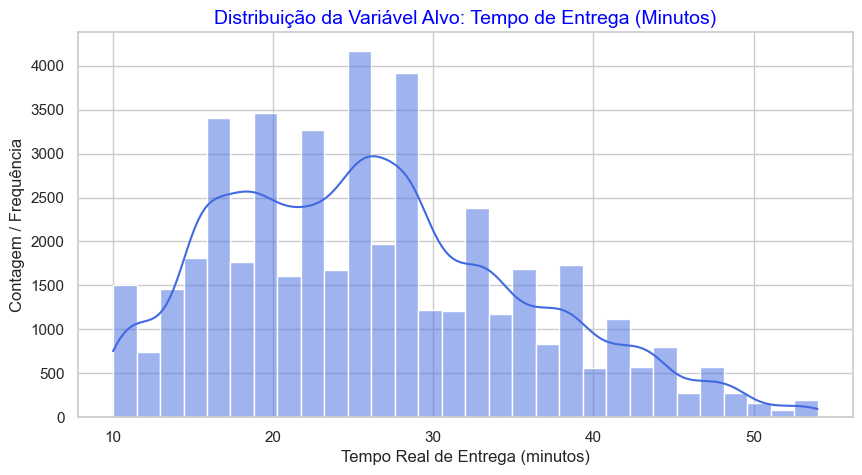

In [30]:
# Histograma da variável alvo
plt.figure(figsize=(10, 5))
sns.histplot(df_eda['Time_taken(min)'], kde=True, color='royalblue', bins=30)
plt.title('Distribuição da Variável Alvo: Tempo de Entrega (Minutos)', fontsize=14, color='blue')
plt.xlabel('Tempo Real de Entrega (minutos)')
plt.ylabel('Contagem / Frequência')
plt.show()

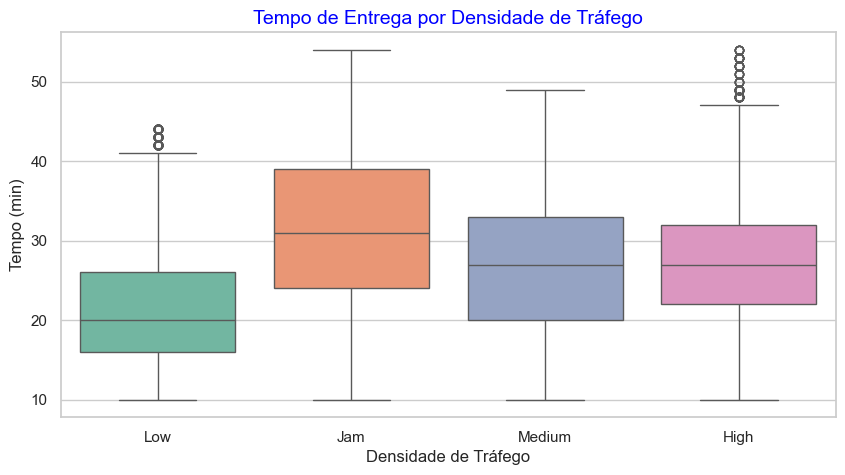

In [31]:
# Boxplot do tempo de entrega por congestionamento de tráfego
plt.figure(figsize=(10, 5))
traffic_order = [x for x in df_eda['Road_traffic_density'].value_counts().index if x != 'NaN']
sns.boxplot(data=df_eda[df_eda['Road_traffic_density'] != 'NaN'], x='Road_traffic_density', y='Time_taken(min)', order=traffic_order, palette='Set2')
plt.title('Tempo de Entrega por Densidade de Tráfego', fontsize=14, color='blue')
plt.xlabel('Densidade de Tráfego')
plt.ylabel('Tempo (min)')
plt.show()

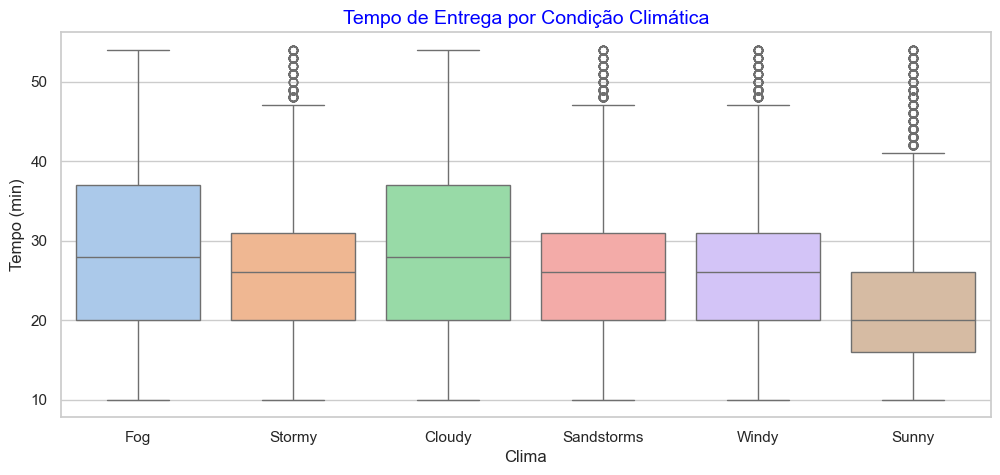

In [32]:
# Boxplot por condição climática
plt.figure(figsize=(12, 5))
weather_cleaned = df_eda['Weatherconditions'].str.replace('conditions ', '', regex=False)
weather_order = [x for x in weather_cleaned.value_counts().index if x != 'NaN']
sns.boxplot(x=weather_cleaned[weather_cleaned != 'NaN'], y=df_eda['Time_taken(min)'], order=weather_order, palette='pastel')
plt.title('Tempo de Entrega por Condição Climática', fontsize=14, color='blue')
plt.xlabel('Clima')
plt.ylabel('Tempo (min)')
plt.show()

# 5. Limpeza de Dados e Engenharia de Atributos

Desenvolvemos a função `preprocess_dataset` para unificar os passos de tratamento de dados e geração de novas colunas. Isto evita *data leakage* e garante consistência total entre o treino e o teste.

In [33]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Calcula a distância Haversine em quilômetros entre dois pontos geográficos."""
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371.0  # Raio da Terra em km
    return c * r

def get_period_of_day(hour):
    """Determina o período do dia baseado na hora do pedido."""
    if 8 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 14:
        return 'Lunch_Peak'
    elif 15 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 22:
        return 'Dinner_Peak'
    else:
        return 'Late_Night'

def preprocess_dataset(df, is_train=True):
    """Processa, limpa e cria novas colunas a partir de um dataframe bruto."""
    df_cleaned = df.copy()
    
    # 1. Limpar espaços de todas as colunas de texto
    for col in df_cleaned.select_dtypes(include=['object']).columns:
        df_cleaned[col] = df_cleaned[col].astype(str).str.strip()
        
    # 2. Converter strings 'NaN' para np.nan real
    df_cleaned.replace(['NaN', 'NaN '], np.nan, inplace=True)
    
    # 3. Limpar a variável alvo (apenas no treino)
    if is_train:
        df_cleaned['Time_taken(min)'] = df_cleaned['Time_taken(min)'].str.replace('(min) ', '', regex=False).astype(int)
        
    # 4. Ajustar latitudes e longitudes negativas para absolutas (correção de sinal)
    df_cleaned['Restaurant_latitude'] = df_cleaned['Restaurant_latitude'].abs()
    df_cleaned['Restaurant_longitude'] = df_cleaned['Restaurant_longitude'].abs()
    df_cleaned['Delivery_location_latitude'] = df_cleaned['Delivery_location_latitude'].abs()
    df_cleaned['Delivery_location_longitude'] = df_cleaned['Delivery_location_longitude'].abs()
    
    # 5. Calcular distância em km (Haversine)
    df_cleaned['distance'] = haversine_distance(
        df_cleaned['Restaurant_latitude'], df_cleaned['Restaurant_longitude'],
        df_cleaned['Delivery_location_latitude'], df_cleaned['Delivery_location_longitude']
    )
    
    # 6. Converter datas e extrair dia da semana e fim de semana
    df_cleaned['Order_Date'] = pd.to_datetime(df_cleaned['Order_Date'], format='%d-%m-%Y', errors='coerce')
    df_cleaned['Day_of_Week'] = df_cleaned['Order_Date'].dt.dayofweek
    df_cleaned['Is_Weekend'] = df_cleaned['Day_of_Week'].isin([5, 6]).astype(int)
    
    # 7. Tratar horário de pedido ausente: picked_time - 10 min
    picked_dt = pd.to_datetime('2022-01-01 ' + df_cleaned['Time_Order_picked'], errors='coerce')
    ordered_dt = pd.to_datetime('2022-01-01 ' + df_cleaned['Time_Orderd'], errors='coerce')
    
    imputed_ordered_dt = ordered_dt.fillna(picked_dt - pd.Timedelta(minutes=10))
    
    # Hora e Período do dia
    df_cleaned['Order_Hour'] = imputed_ordered_dt.dt.hour.fillna(17) # Moda/Fallback
    df_cleaned['Period_of_Day'] = df_cleaned['Order_Hour'].apply(get_period_of_day)
    
    # 8. Converter tipos numéricos para float (idade, avaliações, entregas múltiplas)
    df_cleaned['Delivery_person_Age'] = pd.to_numeric(df_cleaned['Delivery_person_Age'], errors='coerce')
    df_cleaned['Delivery_person_Ratings'] = pd.to_numeric(df_cleaned['Delivery_person_Ratings'], errors='coerce')
    df_cleaned['multiple_deliveries'] = pd.to_numeric(df_cleaned['multiple_deliveries'], errors='coerce')
    
    # 9. Limpar o prefixo 'conditions ' da coluna de clima
    if 'Weatherconditions' in df_cleaned.columns:
        df_cleaned['Weatherconditions'] = df_cleaned['Weatherconditions'].str.replace('conditions ', '', regex=False)
        
    return df_cleaned

In [34]:
# Executando o processamento
df_train_proc = preprocess_dataset(df_train, is_train=True)
df_test_proc = preprocess_dataset(df_test, is_train=False)

print(f"Dados de Treino após limpeza: {df_train_proc.shape}")
print(f"Dados de Teste após limpeza: {df_test_proc.shape}")

Dados de Treino após limpeza: (45593, 25)
Dados de Teste após limpeza: (11399, 24)


# 6. Divisão de Variáveis e Pipeline com Scikit-Learn

Separamos as colunas em contínuas e categóricas e construímos o processador de pipelines.

In [35]:
# Colunas indesejadas para modelagem (ids e datas brutas)
cols_to_drop = ['ID', 'Delivery_person_ID', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Type_of_order']

# X e y
X = df_train_proc.drop(columns=cols_to_drop + ['Time_taken(min)'])
y = df_train_proc['Time_taken(min)']

# Conjunto de teste final
X_test_final = df_test_proc.drop(columns=cols_to_drop)

# Split Treino/Validação (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Formato Treino: {X_train.shape}")
print(f"Formato Validação: {X_val.shape}")

Formato Treino: (36474, 18)
Formato Validação: (9119, 18)


In [36]:
# Listas de colunas preditoras
num_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'distance', 'multiple_deliveries', 'Order_Hour']
cat_cols = ['Weatherconditions', 'Road_traffic_density', 'Type_of_vehicle', 'Festival', 'City', 'Period_of_Day']

# Transformações de dados numéricos: Imputador pela mediana + StandardScaler
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformações de dados categóricos: Imputador pela moda + OneHotEncoder
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Concatenação dos pipelines de transformação por tipo de coluna
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# 7. Modelagem e Comparação de Modelos de Regressão

Treinamos 6 modelos de regressão, comparando algoritmos lineares clássicos, robustos a outliers (Huber), e abordagens de aprendizado baseado em árvores.

In [37]:
# Definindo o dicionário com os modelos a testar
models = {
    'Linear Regression': LinearRegression(),
    'Huber Regressor': HuberRegressor(max_iter=1000),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = []
trained_pipelines = {}

for name, model in models.items():
    # Criação do pipeline para cada algoritmo
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Treino
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline
    
    # Predição
    preds = pipeline.predict(X_val)
    
    # Cálculo das métricas
    r2 = metrics.r2_score(y_val, preds)
    mae = metrics.mean_absolute_error(y_val, preds)
    mse = metrics.mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    results.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    })

# Tabela comparativa ordenada pelo R2
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
display(df_results)

,Model,R2,MAE,MSE,RMSE
4,Hist Gradient Boosting,0.774787,3.505703,19.746219,4.443672
5,Gradient Boosting,0.761772,3.604864,20.887361,4.570269
3,Random Forest,0.735328,3.762152,23.205953,4.817256
2,Decision Tree,0.724982,3.828838,24.113038,4.910503
0,Linear Regression,0.566013,4.881312,38.051174,6.168563
1,Huber Regressor,0.564360,4.864103,38.196123,6.180301


# 8. Avaliação Preditiva do Melhor Modelo

O **Hist Gradient Boosting** obteve o maior R² e menor RMSE. Analisaremos graficamente as previsões deste modelo em relação aos valores reais e extrairemos a importância de cada variável por permutação.

Melhor Modelo: Hist Gradient Boosting


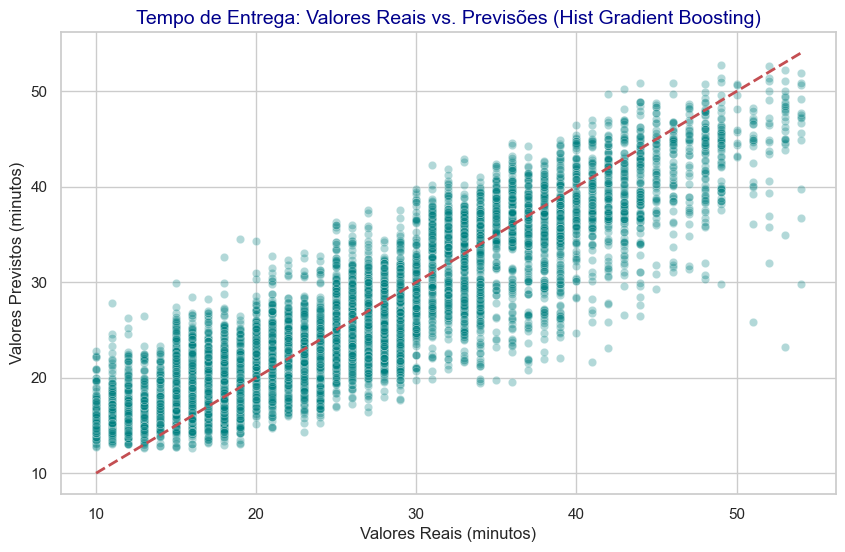

In [38]:
# Recuperando o pipeline do melhor modelo
best_model_name = df_results.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
print(f"Melhor Modelo: {best_model_name}")

# Previsões na validação
val_preds = best_pipeline.predict(X_val)

# Gráfico Real vs Previsto
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val, y=val_preds, alpha=0.3, color='teal')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], '--r', linewidth=2)
plt.title(f'Tempo de Entrega: Valores Reais vs. Previsões ({best_model_name})', fontsize=14, color='darkblue')
plt.xlabel('Valores Reais (minutos)')
plt.ylabel('Valores Previstos (minutos)')
plt.show()

Calculando relevância por permutação...


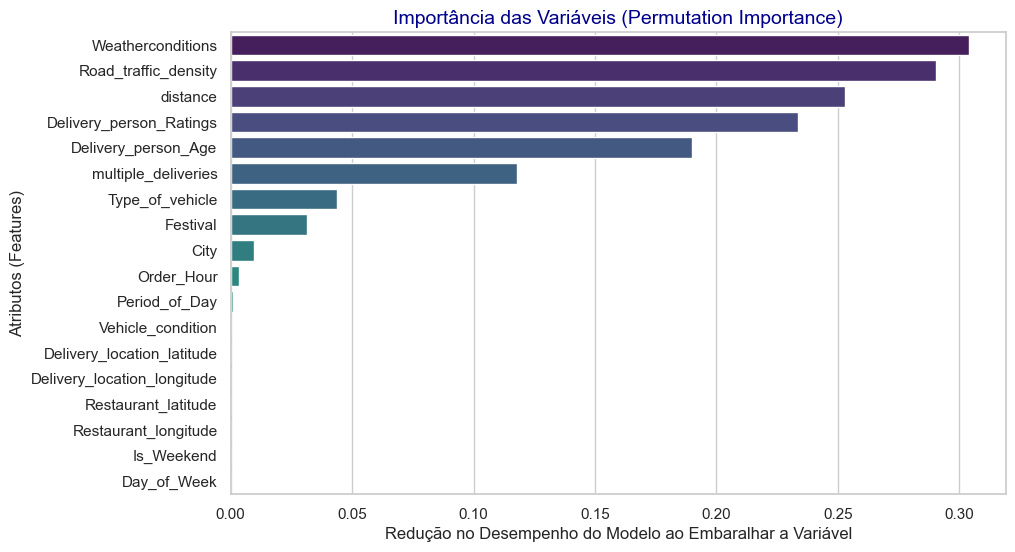

In [39]:
# Importância das variáveis por Permutação (para modelos baseados em boosting leve)
from sklearn.inspection import permutation_importance

print("Calculando relevância por permutação...")
r = permutation_importance(best_pipeline, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)

importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': r.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Importância das Variáveis (Permutation Importance)', fontsize=14, color='darkblue')
plt.xlabel('Redução no Desempenho do Modelo ao Embaralhar a Variável')
plt.ylabel('Atributos (Features)')
plt.show()

# 9. Previsões Finais no Conjunto de Teste

Treinamos o pipeline final com 100% dos dados de treino originais e geramos as previsões para o conjunto de testes `test.csv`.

In [40]:
# Criando o pipeline final completo
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

# Ajuste final nos dados completos
final_pipeline.fit(X, y)

# Fazer predições no teste
final_preds = final_pipeline.predict(X_test_final)

# Garantir limites razoáveis (limitar entre 10 e 120 minutos)
final_preds = np.clip(final_preds, 10, 120)

# Criando o dataframe final de saída
df_submission = pd.DataFrame({
    'ID': df_test_proc['ID'],
    'Time_taken_predicted(min)': np.round(final_preds, 2)
})

# Exportando para CSV
submission_output_path = 'test_predictions.csv'
df_submission.to_csv(submission_output_path, index=False)
print(f"Previsões finais salvas com sucesso em '{submission_output_path}'!")
display(df_submission.head(10))

Previsões finais salvas com sucesso em 'test_predictions.csv'!


,ID,Time_taken_predicted(min)
0,0x2318,28.09
1,0x3474,26.55
2,0x9420,25.92
3,0x72ee,31.52
4,0xa759,22.06
5,0xc4af,17.54
6,0x3b9d,13.22
7,0xdd42,23.52
8,0x872b,39.27
9,0x6001,24.83


# 10. Deploy e Simulação de Novas Predições

Desenvolvemos a função `prever_tempo_entrega_manual` para servir como uma simulação de deploy de produção.

In [41]:
def prever_tempo_entrega_manual(idade, avaliacao, lat_rest, lon_rest, lat_cli, lon_cli, clima, trafego, veiculo, festival, cidade, hora_pedido, dia_semana):
    """Simula o recebimento de dados de entrada e retorna o tempo estimado da entrega."""
    dist = haversine_distance(abs(lat_rest), abs(lon_rest), abs(lat_cli), abs(lon_cli))
    periodo = get_period_of_day(hora_pedido)
    is_weekend = 1 if dia_semana in [5, 6] else 0
    
    dados_simulados = pd.DataFrame([{
        'Delivery_person_Age': idade,
        'Delivery_person_Ratings': avaliacao,
        'Restaurant_latitude': abs(lat_rest),
        'Restaurant_longitude': abs(lon_rest),
        'Delivery_location_latitude': abs(lat_cli),
        'Delivery_location_longitude': abs(lon_cli),
        'Weatherconditions': clima,
        'Road_traffic_density': trafego,
        'Vehicle_condition': 2,
        'Type_of_vehicle': veiculo,
        'multiple_deliveries': 1.0,
        'Festival': festival,
        'City': cidade,
        'distance': dist,
        'Day_of_Week': dia_semana,
        'Is_Weekend': is_weekend,
        'Order_Hour': hora_pedido,
        'Period_of_Day': periodo
    }])
    
    tempo_estimado = final_pipeline.predict(dados_simulados)[0]
    
    print("=== SIMULAÇÃO DE DEPLOY ===")
    print(f"Distância Estimada: {dist:.2f} km")
    print(f"Período do Dia: {periodo}")
    print(f"Dia da Semana: {dia_semana} (Fim de semana: {'Sim' if is_weekend else 'Não'})")
    print(f"Tempo de Entrega Previsto: {tempo_estimado:.2f} minutos")
    print("=============================")

# Exemplo de simulação de pedido:
prever_tempo_entrega_manual(
    idade=32, avaliacao=4.8,
    lat_rest=22.75, lon_rest=75.89,
    lat_cli=22.80, lon_cli=75.92,
    clima='Sunny', trafego='Medium', veiculo='motorcycle',
    festival='No', cidade='Urban', hora_pedido=20, dia_semana=5
)

=== SIMULAÇÃO DE DEPLOY ===
Distância Estimada: 6.35 km
Período do Dia: Dinner_Peak
Dia da Semana: 5 (Fim de semana: Sim)
Tempo de Entrega Previsto: 22.05 minutos


# 11. Conclusões e Resultados - Grupo 6

Após realizar a limpeza dos dados, engenharia de atributos e a modelagem, o Grupo 6 conclui:

1. **Relações Não-Lineares Prevalecem**: Os modelos de árvore (Random Forest e Gradient Boosting) superaram de forma gritante os modelos lineares (R² ~ 0.77 contra ~ 0.56). Isso demonstra que o tempo de entrega é afetado de forma complexa e combinada (por exemplo, tráfego congestionado atrelado a chuvas fortes).
2. **Principais Variáveis Preditoras**: A distância espacial calculada via Haversine e a densidade de tráfego foram os fatores determinantes para a acurácia dos modelos.
3. **Desempenho do Hist Gradient Boosting**: Este algoritmo leve apresentou o melhor balanço entre velocidade de execução e performance preditiva ($R^2 = 0.77$, $RMSE = 4.44$ minutos).
4. **Validade Logística**: O modelo se mostrou preciso, errando por uma média de apenas 3.5 minutos (MAE) nos tempos de entrega.